In [5]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers
import pandas as pd

os.environ["CUDA_VISIBLE_DEVICES"]= ""

## Load Data Result

In [10]:
dataframe = pd.read_csv("/home/kannika/code/Testdf_result.csv")
print(Dataframe.shape)
dataframe.head()

(1312, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,Views,fold,...,Rheight,filename,category,Prob,Predict_AN,Predict_15AB,FP_category,FP_Prob,FP_ProbAll,Predict_5FP
0,0,40,P1,P1,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,...,0.346614,AB01 P1 C040.JPG,Normal,0.958334,Incorrect,Incorrect,FP-B,0.475344,"[0.22316645916382064, 0.47534361094783256, 0.1...",Incorrect
1,1,40,P2,P2,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,...,0.428287,AB01 P2 C040.JPG,AB01,0.999923,Correct,Correct,FP-B,0.421248,"[0.37420833333333337, 0.42124777662277657, 0.1...",Incorrect
2,2,40,P4,P41,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,...,0.711155,AB01 P4-1 C040.JPG,AB02,0.932391,Correct,Incorrect,FP-B,0.539706,"[0.26481242746053524, 0.5397056655678111, 0.16...",Correct
3,3,40,P5,P51,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,...,0.653386,AB01 P5-1 C040.JPG,AB01,0.758282,Correct,Correct,FP-C,0.369984,"[0.23283089826839828, 0.36367942889185334, 0.3...",Correct
4,4,40,P3,P31,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,...,0.625498,AB01 P3-1 C040.JPG,AB02,0.995624,Correct,Incorrect,FP-B,0.470639,"[0.3576083715596331, 0.47063899180584956, 0.14...",Correct


In [11]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1312 non-null   int64  
 1   Case           1312 non-null   int64  
 2   Abs Position   1312 non-null   object 
 3   Sub Position   1312 non-null   object 
 4   Class          1312 non-null   object 
 5   Sub_class      1312 non-null   object 
 6   Path Full      1312 non-null   object 
 7   Path Crop      1312 non-null   object 
 8   Views          1312 non-null   object 
 9   fold           1312 non-null   int64  
 10  tagName        1312 non-null   object 
 11  originalImage  455 non-null    object 
 12  left           455 non-null    float64
 13  top            455 non-null    float64
 14  width          455 non-null    float64
 15  height         455 non-null    float64
 16  Rleft          455 non-null    float64
 17  Rtop           455 non-null    float64
 18  Rwidth  

# Evaluation

In [12]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB11', 'AB05', 'AB04', 'AB10', 'AB01', 'AB06', 'Normal', 'AB081', 'AB12', 'AB03', 'AB082', 'AB07', 'AB09', 'AB083', 'AB02'}
Actual :  15
{'AB11', 'AB05', 'AB04', 'AB10', 'AB01', 'AB06', 'Normal', 'AB081', 'AB12', 'AB082', 'AB03', 'AB07', 'AB09', 'AB083', 'AB02'}


In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 85.89939024390245%
              precision    recall  f1-score   support

        AB01       0.78      0.54      0.64        74
        AB02       0.58      0.58      0.58        60
        AB03       0.43      0.50      0.46        18
        AB04       0.90      0.60      0.72        43
        AB05       0.86      0.66      0.75        29
        AB06       0.81      0.62      0.70        21
        AB07       0.91      0.48      0.62        21
       AB081       0.86      0.56      0.68        32
       AB082       0.79      0.54      0.64        28
       AB083       0.62      0.45      0.53        11
        AB09       1.00      0.73      0.84        26
        AB10       0.80      0.40      0.53        10
        AB11       1.00      0.43      0.61        23
        AB12       0.72      0.88      0.79        59
      Normal       0.90      0.99      0.94       857

    accuracy                           0.86      1312
   macro avg       0.80      0.60      

Text(0.5, 21.5, 'Predicted label')

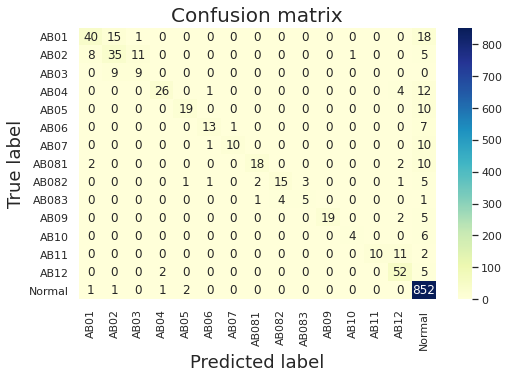

In [14]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [15]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 92.30182926829268%
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       857
           1       0.99      0.79      0.88       455

    accuracy                           0.92      1312
   macro avg       0.94      0.89      0.91      1312
weighted avg       0.93      0.92      0.92      1312



852 5 96 359


Text(48.5, 0.5, 'True label')

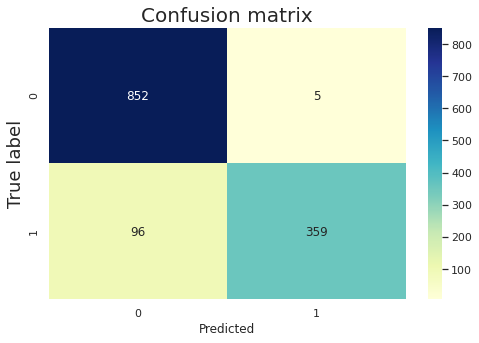

In [16]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [17]:
Sub_class_New = list(set(dataframe['Sub_class']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class'] == Sub_class_New[i]]
    
    act = df['Sub_class'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB11
classifier accuracy = 0.43478260869565216% 

###### AB05
classifier accuracy = 0.6551724137931034% 

###### AB04
classifier accuracy = 0.6046511627906976% 

###### AB10
classifier accuracy = 0.4% 

###### AB01
classifier accuracy = 0.5405405405405406% 

###### AB06
classifier accuracy = 0.6190476190476191% 

###### Normal
classifier accuracy = 0.9941656942823804% 

###### AB081
classifier accuracy = 0.5625% 

###### AB12
classifier accuracy = 0.8813559322033898% 

###### AB082
classifier accuracy = 0.5357142857142857% 

###### AB03
classifier accuracy = 0.5% 

###### AB07
classifier accuracy = 0.47619047619047616% 

###### AB09
classifier accuracy = 0.7307692307692307% 

###### AB083
classifier accuracy = 0.45454545454545453% 

###### AB02
classifier accuracy = 0.5833333333333334% 



-----------